## Coastal shelf

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [ ]:
from shapely.geometry import Point
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

In [4]:
import netCDF4 as nc
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator

## Net cf

In [5]:
# from https://www.gebco.net/data-products/gridded-bathymetry-data
ds = nc.Dataset('GEBCO_2026.nc')


In [6]:
ds.variables.keys()

dict_keys(['lon', 'lat', 'crs', 'elevation'])

In [7]:
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]
crs = ds.variables['crs'][:]
elevation = ds.variables['elevation'][:]  

In [8]:
elevation

masked_array(
  data=[[ 2829,  2829,  2829, ...,  2829,  2829,  2829],
        [ 2830,  2830,  2830, ...,  2830,  2830,  2830],
        [ 2831,  2831,  2831, ...,  2831,  2831,  2831],
        ...,
        [-4221, -4221, -4221, ..., -4221, -4221, -4221],
        [-4222, -4222, -4222, ..., -4222, -4222, -4222],
        [-4225, -4225, -4225, ..., -4225, -4225, -4225]],
  mask=False,
  fill_value=np.int64(999999),
  dtype=int16)

In [9]:
step = 10  # take every 10th point -> reduces size by 100x

lat = ds.variables['lat'][::step]
lon = ds.variables['lon'][::step]
elevation = ds.variables['elevation'][::step, ::step]

lon_grid, lat_grid = np.meshgrid(lon, lat)
shelf_mask = (elevation > -200) & (elevation < 0)

df_shelf = pd.DataFrame({
    'Lat': lat_grid[shelf_mask],
    'Lon': lon_grid[shelf_mask],
    'elevation': elevation[shelf_mask]
})

In [10]:
df_shelf

,Lat,Lon,elevation
0,-81.206250,161.210417,-173
1,-81.164583,160.835417,-61
2,-81.164583,160.877083,-28
3,-81.164583,161.168750,-167
4,-81.081250,160.793750,-43
...,...,...,...
2160417,84.043750,-35.081250,-190
2160418,84.043750,-35.039583,-189
2160419,84.043750,-34.997917,-189
2160420,84.043750,-34.956250,-189


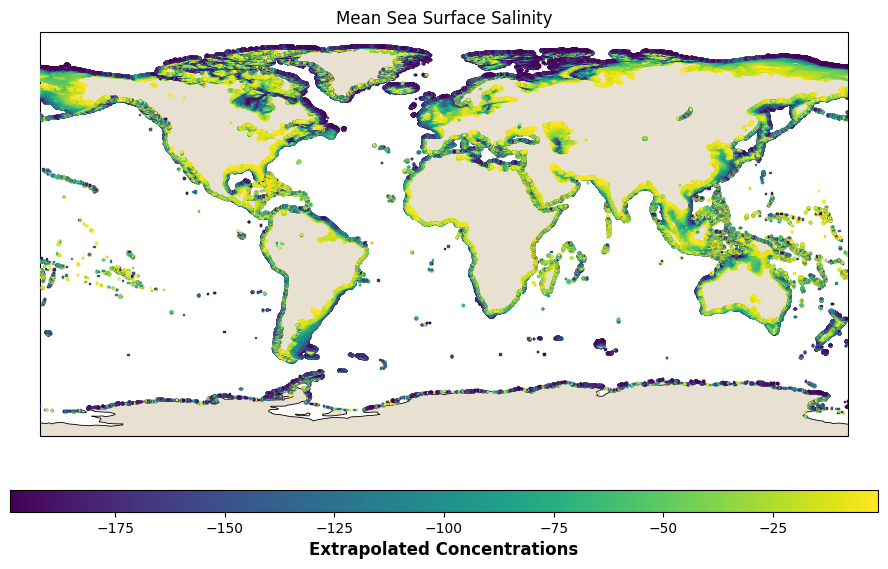

In [12]:
Lon_grid = df_shelf['Lon']
Lat_grid = df_shelf['Lat']
Elevation = df_shelf['elevation']

fig = plt.figure(figsize=(14, 7))

ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
#ax.set_extent([115, 135, 29, 42], crs=ccrs.PlateCarree())

#im = ax.pcolormesh(Lon_grid, Lat_grid, Elevation, cmap="RdYlBu", transform=ccrs.PlateCarree())
#ax.scatter(Lon_grid, Lat_grid, color="black", s=1, transform=ccrs.PlateCarree())

mesh = ax.scatter(Lon_grid, Lat_grid,
                  c=Elevation,
                  cmap='viridis',
                  vmin = min(Elevation),
                  vmax = max(Elevation),
                  marker='s',  # square marker
                  s=1,       # ADUJST HERE TO MAKE A GOOD SQUARES
                  zorder=4,
                  transform=ccrs.PlateCarree())


cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Extrapolated Concentrations', fontsize=12, fontweight='bold')

#plt.colorbar(im, ax=ax, label="Mean Sea Surface Salinity (PSU)")

plt.title("Mean Sea Surface Salinity")
plt.show()

In [13]:

shape_data = df_shelf

    # Assign each point to its 1° grid cell center
shape_data['lat_bin'] = np.floor(shape_data['Lat']) + 0.5
shape_data['lon_bin'] = np.floor(shape_data['Lon']) + 0.5

    # Average only the MP concentration per cell
df_gridded = shape_data.groupby(['lat_bin', 'lon_bin']).agg(
                                            El_mean=('elevation', 'mean'),
                                            MP_std=('elevation', 'std'),   # keep track of within-cell variance
                                            n_points=('elevation', 'count')
                                            ).reset_index()
    
    # Rename coordinates
df_gridded = df_gridded.rename(columns={'lat_bin': 'Lat_center', 'lon_bin': 'Lon_center', 'Elevation': 'elevation'})



In [14]:
df_gridded

,Lat_center,Lon_center,El_mean,MP_std,n_points
0,-81.5,160.5,-44.000000,16.522712,3
1,-81.5,161.5,-170.000000,4.242641,2
2,-79.5,160.5,-9.500000,2.121320,2
3,-79.5,175.5,-178.000000,NaN,1
4,-79.5,176.5,-88.000000,121.622366,2
...,...,...,...,...,...
10163,84.5,-35.5,-187.051282,6.480532,39
10164,84.5,-34.5,-189.600000,5.639149,5
10165,84.5,-32.5,-171.947368,14.001880,19
10166,84.5,-31.5,-156.083333,12.109037,12


In [15]:
df_gridded.to_csv('Continental shelf grid.csv', index=False)

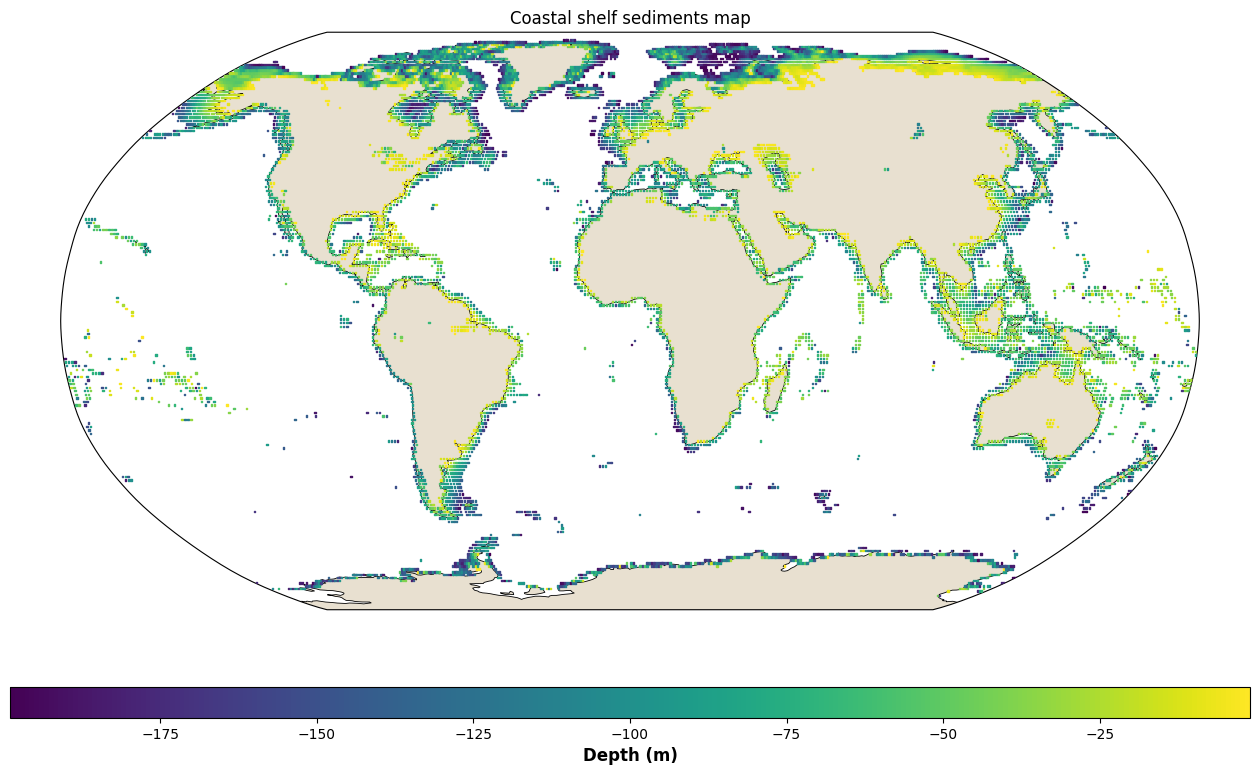

In [17]:
Lon_grid = df_gridded['Lon_center']
Lat_grid = df_gridded['Lat_center']
Elevation = df_gridded['El_mean']

fig = plt.figure(figsize=(20, 10))

ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
#ax.set_extent([115, 135, 29, 42], crs=ccrs.PlateCarree())

#im = ax.pcolormesh(Lon_grid, Lat_grid, Elevation, cmap="RdYlBu", transform=ccrs.PlateCarree())
#ax.scatter(Lon_grid, Lat_grid, color="black", s=10, transform=ccrs.PlateCarree())

mesh = ax.scatter(Lon_grid, Lat_grid,
                  c=Elevation,
                  cmap='viridis',
                  vmin = min(Elevation),
                  vmax = max(Elevation),
                  marker='s',  # square marker
                  s=1,       # ADUJST HERE TO MAKE A GOOD SQUARES
                  zorder=4,
                  transform=ccrs.PlateCarree())


cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Depth (m)', fontsize=12, fontweight='bold')

#plt.colorbar(im, ax=ax, label="Mean Sea Surface Salinity (PSU)")

plt.title("Coastal shelf sediments map")
plt.show()

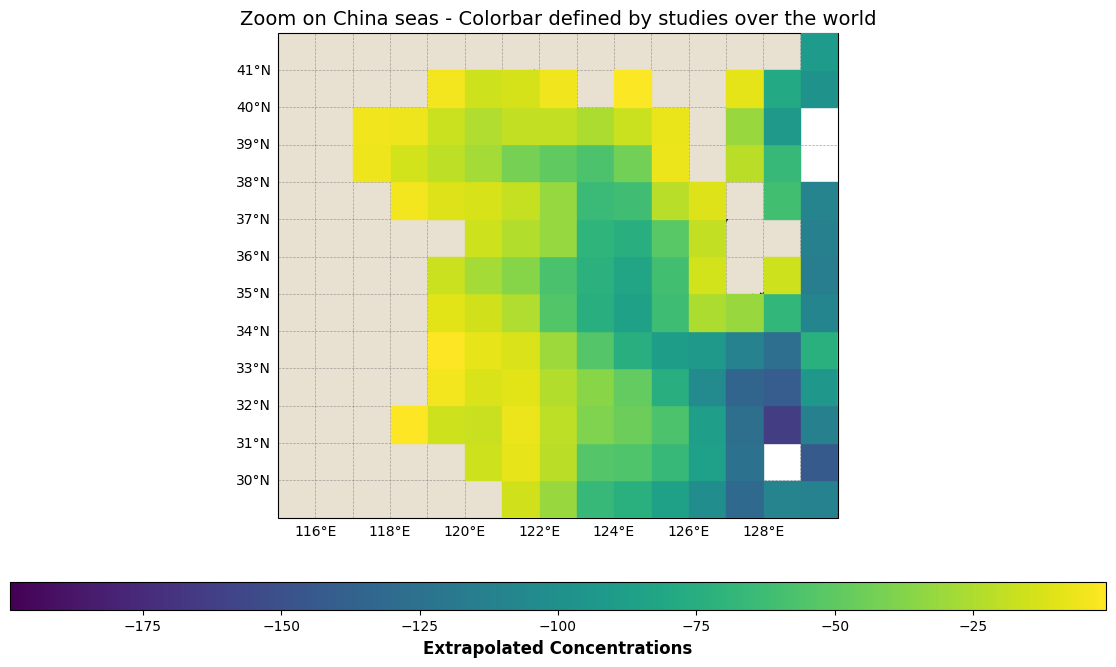

In [ ]:
Lon_grid = df_gridded['Lon_center']
Lat_grid = df_gridded['Lat_center']
Elevation = df_gridded['El_mean']

vmin = min(Elevation)
vmax = max(Elevation)
#norm = LogNorm(vmin=vmin, vmax=vmax)

cell_size = 1  # your grid resolution in degrees

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.set_extent([115, 130, 29, 42], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
# Control spacing of ticks
gl.xlocator = MultipleLocator(1)  # 1° longitude
gl.ylocator = MultipleLocator(1)  # 1° latitude

# Optional: adjust label positions
gl.top_labels = False
gl.right_labels = False


mesh = ax.scatter(Lon_grid, Lat_grid,
                  c=Elevation,
                  cmap='viridis',
                  vmin = min(Elevation),
                  vmax = max(Elevation),
                  marker='s',  # square marker
                  s=690,       # ADUJST HERE TO MAKE A GOOD SQUARES
                  zorder=4,
                  transform=ccrs.PlateCarree())


cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.1, shrink=0.8, aspect=40)
cbar.set_label('Extrapolated Concentrations', fontsize=12, fontweight='bold')

plt.title("Zoom on China seas - Colorbar defined by studies over the world", fontsize=14)
plt.tight_layout()
plt.show()